In [1]:
!hostname

gpu03


## Neural Network testing
#### Trained with `UNet.py`

In [1]:
import matplotlib.image as mpimg

In [2]:
import glob
import os
import numpy as np

# Path to your folder
path = "/home/PERSONALE/nicolo.fiaba/.cache/kagglehub/datasets/aryankaushik005/pixart/versions/1/PixART dataset/automobile"

# Get all JPG image paths
image_files = glob.glob(os.path.join(path, "*.jpg"))

# Read and store all images in a list
images = [mpimg.imread(img_path) for img_path in image_files]

# Convert to numpy array (optional, for training)
images = np.array(images, dtype=np.float32)

print("Loaded images:", len(images))
print("Shape of one image:", images[0].shape)

Loaded images: 200
Shape of one image: (512, 512, 3)


In [3]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.layers import Input, Conv2D, MaxPool2D, UpSampling2D, Conv2DTranspose, Reshape, concatenate, Dropout, Rescaling, LeakyReLU
from keras.models import Model
from astropy.io import fits
import matplotlib.pyplot as plt
from gelsa import visu
from tqdm.notebook import tqdm

2025-11-04 21:03:58.232821: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-04 21:03:58.262876: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-04 21:03:58.262899: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-04 21:03:58.262905: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-04 21:03:58.268252: I tensorflow/core/platform/cpu_feature_g

In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    tf.config.set_visible_devices(gpus[2], 'GPU')
    logical_gpus = tf.config.list_logical_devices('GPU')
  except RuntimeError as e:
    print(e)

2025-11-04 21:04:02.119843: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 78570 MB memory:  -> device: 2, name: H100 80GB HBM3, pci bus id: 0000:cb:00.0, compute capability: 9.0


In [5]:
print("TF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TF version: 2.14.0
Built with CUDA: True
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU')]


### Train and test set split

In [6]:
# test set is 10% of the whole dataset
x_train, x_test, y_train, y_test = train_test_split(
    images, images, test_size=0.1, random_state=42)

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42)

### Rescaling images

In ML it's crucial to renormalize the data in the (0, 1) range or (-1, 1). 

Everything is **rescaled** with the **same factor**, the maximum flux is the images with emission lines (since they are the brightest).

**NB**: The mask dataset is already normalized [0, 1]

In [7]:
# rescale = Rescaling(1./(x_max - x_min), offset=-x_min/(x_max - x_min), input_shape=(512, 512, 1))
rescale = Rescaling(1./255, input_shape=(512, 512, 3))

In [8]:

train = rescale(y_train)
val = rescale(y_val)
test = rescale(y_test)


In [9]:
# train = y_train.astype(np.float32) / 255.0
# val   = y_val.astype(np.float32)   / 255.0
# test  = y_test.astype(np.float32)  / 255.0

In [10]:
# w can easily become an hyperparameter to be optimized
def weighted_L2_loss(w):
    def loss(y_true, y_pred):
        error = K.square(y_true - y_pred)
        error = K.switch(K.less(y_true, tf.reduce_mean(train)), w * error, error)
        return error 
    return loss

def pow_downweight_loss(alpha):
    def loss(y_true, y_pred):
        y_true_clipped = K.clip(y_true, K.epsilon(), 1.0)
        y_pred_clipped = K.clip(y_pred, K.epsilon(), 1.0)

        y_true_rescaled = K.pow(y_true_clipped, alpha)
        y_pred_rescaled = K.pow(y_pred_clipped, alpha)

        error = K.square(y_true_rescaled - y_pred_rescaled)
        return error
    return K.mean(loss)

def log_downweight_loss(y_true, y_pred):
    
    y_true_rescaled = tf.math.log(1 + y_true)
    y_pred_rescaled = tf.math.log(1 + y_pred)

    error = K.square(y_true_rescaled - y_pred_rescaled)
    return K.mean(error)

In [11]:
image_size = (train.shape[1], train.shape[2])
print("Images in training set:", len(train), 
      "\nImages in validation set:", len(val), 
      "\nImages in test set:", len(test), 
      "\nImage size:", image_size)

Images in training set: 144 
Images in validation set: 36 
Images in test set: 20 
Image size: (512, 512)


### Define the Neural Network

Architecture: [Image Inpainting Using AutoEncoder and Guided Selection of Predicted Pixels by Mohammad H. Givkashi](https://arxiv.org/pdf/2112.09262)

In [12]:
# Model 2: U-Net (usually used for Image Segmentation of Biomedical images)
# Define construction functions for fundamental blocks

def double_conv_block(x, n_filters):

    x = Conv2D(n_filters, 3, padding = "same", kernel_initializer = "he_normal")(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = Conv2D(n_filters, 3, padding = "same", kernel_initializer = "he_normal")(x)
    x = LeakyReLU(alpha=0.1)(x)

    return x

def downsample_block(x, n_filters):
    f = double_conv_block(x, n_filters)
    p = MaxPool2D(2)(f)
    # p = Dropout(0.3)(p)
    return f, p

def upsample_block(x, conv_features, n_filters):
    # 3: kernel size
    # 2: strides
    x = Conv2DTranspose(n_filters, 3, 2, padding='same')(x)
    x = concatenate([x, conv_features])
    # x = Dropout(0.3)(x)
    x = double_conv_block(x, n_filters)
    return x

In [13]:
# Build the U-Net model

def make_unet_model(image_size):
    inputs = Input(shape=(image_size[0], image_size[1], 3))

    # Encoder
    f1, p1 = downsample_block(inputs, 64)
    f2, p2 = downsample_block(p1, 128)
    f3, p3 = downsample_block(p2, 256)
    f4, p4 = downsample_block(p3, 512)
    
    # Bottleneck
    bottleneck = double_conv_block(p4, 1024)
    
    # Decoder
    u6 = upsample_block(bottleneck, f4, 512)
    u7 = upsample_block(u6, f3, 256)
    u8 = upsample_block(u7, f2, 128)
    u9 = upsample_block(u8, f1, 64)

    # Output
    outputs = Conv2D(3, 1, padding='same', activation='sigmoid')(u9)

    unet_model = Model(inputs, outputs, name='U-Net')

    return unet_model

In [14]:
unet_model = make_unet_model(image_size)

unet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='mse',
                  metrics=['mse'])

# unet_model.summary()

In [15]:
import os
checkpoint_path = "/scratch/astro/nicolo.fiaba/training_weights/unet_ckp.weights.h5"
checkpoint_dir = os.path.dirname(checkpoint_path)

# Create a callback that saves the model's weights

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                 monitor='val_loss',
                                                 save_best_only=True,
                                                 save_weights_only=True,
                                                 verbose=1)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                           patience=3,
                                           restore_best_weights=True,
                                           start_from_epoch=100)

### Defining hyperparameters

In [16]:
# Set hyerparameters
EPOCHS = 500
BATCH_SIZE = 16
LEARNING_RATE = 1e-4

In [17]:
print("Running for", EPOCHS, "epochs")

Running for 500 epochs


### Training on GPU (`gpu03`)

In [20]:
# autoencoder_2 = make_autoencoder_model_2(image_size)

hist = unet_model.fit(
    train[:4], train[:4],
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(val[:4], val[:4]),
    # callbacks=[cp_callback],
    verbose=2
)
# autoencoder_2.evaluate(test_mask)

Epoch 1/500
1/1 - 0s - loss: 0.1131 - mse: 0.1131 - val_loss: 0.0890 - val_mse: 0.0890 - 490ms/epoch - 490ms/step
Epoch 2/500
1/1 - 0s - loss: 0.1073 - mse: 0.1073 - val_loss: 0.0852 - val_mse: 0.0852 - 281ms/epoch - 281ms/step
Epoch 3/500
1/1 - 0s - loss: 0.1022 - mse: 0.1022 - val_loss: 0.0848 - val_mse: 0.0848 - 282ms/epoch - 282ms/step
Epoch 4/500
1/1 - 0s - loss: 0.0982 - mse: 0.0982 - val_loss: 0.0825 - val_mse: 0.0825 - 280ms/epoch - 280ms/step
Epoch 5/500
1/1 - 0s - loss: 0.0930 - mse: 0.0930 - val_loss: 0.0727 - val_mse: 0.0727 - 278ms/epoch - 278ms/step
Epoch 6/500
1/1 - 0s - loss: 0.0853 - mse: 0.0853 - val_loss: 0.0661 - val_mse: 0.0661 - 278ms/epoch - 278ms/step
Epoch 7/500
1/1 - 0s - loss: 0.0778 - mse: 0.0778 - val_loss: 0.0656 - val_mse: 0.0656 - 279ms/epoch - 279ms/step
Epoch 8/500
1/1 - 0s - loss: 0.0722 - mse: 0.0722 - val_loss: 0.0551 - val_mse: 0.0551 - 278ms/epoch - 278ms/step
Epoch 9/500
1/1 - 0s - loss: 0.0661 - mse: 0.0661 - val_loss: 0.0493 - val_mse: 0.0493 -

### Loading trained model and evaluation

In [21]:
from keras.models import load_model
saved_model = load_model('/scratch/astro/nicolo.fiaba/trained_models/unet_model_cars.h5', compile=False)

saved_model.compile(optimizer=tf.keras.optimizers.Adam(),
                  loss='mse',
                  metrics="mse")
# saved_model.summary()

---

In [22]:
pred_trained = saved_model.predict(test)
pred_trained = np.squeeze(pred_trained)

1/1 [==============================] - 12s 12s/step


In [23]:
pred_untrained = unet_model.predict(test)
pred_untrained = np.squeeze(pred_untrained)

1/1 [==============================] - 0s 158ms/step


2


Text(0.5, 0.98, 'Index: 2')

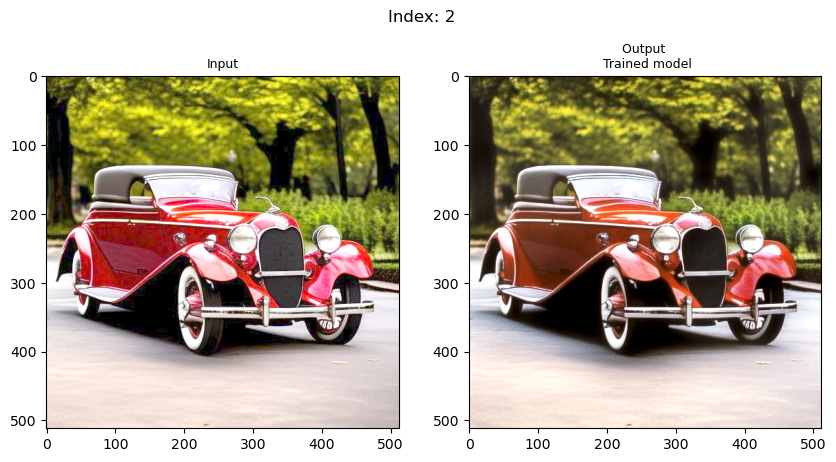

In [26]:
import random
index = 2
print(index)

fig, axs = plt.subplots(1, 2, figsize=(10,5))
lis = [test, pred_untrained]
titles = ['Input', 'Output \n Trained model']

for i, ax in enumerate(axs.flatten()):
    ax.imshow(visu.normalize_image(lis[i][index], levels=(5, 95)), aspect=1)
    ax.set_title(titles[i], fontsize=9)
plt.suptitle("Index: {}".format(index))
# plt.savefig('/scratch/astro/nicolo.fiaba/ex1.png')

Let's compute the reconstruction error for each reconstructed image

In [45]:
tf.reduce_mean(tf.keras.losses.MSE(
    test, pred_trained
))

<tf.Tensor: shape=(), dtype=float32, numpy=0.001671737>

In [49]:
w=0.1
error = K.square(test - pred_trained)
error = K.switch(K.less(test, tf.reduce_mean(train)), w * error, error)

In [52]:
tf.reduce_mean(error)

<tf.Tensor: shape=(), dtype=float32, numpy=5.165408e-05>

### Measuring reconstruction error

In [ ]:
mse = tf.keras.losses.MeanSquaredError(None)
# Global average error
recon_error = mse(scale_img.reshape(1548, -1), img_regenerated.reshape(1548, -1))

In [ ]:
print(recon_error.numpy())

In [ ]:
recon_error[769].numpy()